# **Content** **Based** **Recommendation** **System**
Content-based recommendation systems recommend items similar to those a user liked in the past, relying on item features (e.g., genre, keywords, text) rather than user interaction data.



**Content:**

1.   Contributor Names
2.   Imports
3.   Load Data
4.   Merge Metadata
5.   Build Content Features
6.   TF-IDF Vectorization
7.   User Purchase History
8.   Build User Profile
9.   Recommendation Function
10.  Example
11.  Evaluation


# 1. Contributor Names

Paula Candiles Puente

# 2. Imports



In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 3. Load Data

In [2]:
products = pd.read_csv("products.csv")
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")
orders = pd.read_csv("orders.csv")
prior = pd.read_csv("order_products__prior.csv")

# 4. Merge Metadata

In [3]:
products = products.merge(aisles, on="aisle_id")
products = products.merge(departments, on="department_id")

# 5. Build Content Features

In [4]:
products["content"] = (
    products["product_name"].fillna('') + " " +
    products["aisle"].fillna('') + " " +
    products["department"].fillna('')
)


# 6. TF-IDF Vectorization

In [5]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(products["content"])

# 7. User Purchase History

In [6]:
prior_orders = orders[orders["eval_set"] == "prior"][["order_id","user_id"]]
user_products = prior.merge(prior_orders, on="order_id")
user_products = user_products[["user_id","product_id"]]

# 8. Build User Profile

In [10]:
def build_user_profile(user_id):
    bought = user_products[user_products.user_id == user_id]["product_id"].unique()
    if len(bought) == 0:
        return None
    idx = products[products.product_id.isin(bought)].index
    return tfidf_matrix[idx].mean(axis=0).A

# 9. Recommender Fucntion

In [11]:
def recommend(user_id, top_n=10):
    profile = build_user_profile(user_id)
    if profile is None:
        return pd.DataFrame(columns=["product_id","product_name","score"])
    similarities = cosine_similarity(profile, tfidf_matrix).ravel()
    recs = products.copy()
    recs["score"] = similarities
    bought = user_products[user_products.user_id == user_id]["product_id"].unique()
    recs = recs[~recs.product_id.isin(bought)]
    recs = recs.sort_values("score", ascending=False)
    return recs[["product_id","product_name","score"]].head(top_n)

# 10. Example Output

In [12]:
result = recommend(user_id=1, top_n=10)
print(result)

       product_id                                     product_name     score
6947         6948                     Organic Original Almond Milk  0.478835
35502       35503                      Organic Vanilla Almond Milk  0.477976
10536       10537  Organic Protein Unsweetened Vanilla Almond Milk  0.471930
6007         6008                                   Organic Apples  0.465306
6346         6347                          Unsweetened Almond Milk  0.464544
43294       43295                  Unsweetened Vanilla Almond Milk  0.457461
39189       39190                  Vanilla Unsweetened Almond Milk  0.457461
14176       14177                            Chocolate Almond Milk  0.453685
19383       19384                             Original Almond Milk  0.432104
11360       11361     Pure Almond Unsweetened Original Almond Milk  0.431748


# 11. Evaluation

**What this section does?**

For a content-based recommender we evaluate against binary relevance:

- 1 = the user actually bought the item in the train set
- 0 = the item was not bought

Then we compare the recommendation score against that binary target.

It evaluates the recommender using the users’ train orders as ground truth. So:

- Precision@K: among the top K recommendations, how many were actually bought
- Recall@K: how much of the user’s true purchased set was recovered
- NDCG: rewards correct recommendations appearing higher in the ranking
- Coverage: how much of the catalog the model is able to recommend
- Diversity: how different the recommended products are from one another
- Serendipity: how different the recommendations are from the user’s purchase history while still being relevant
- RMSE / MAE: computed on binary relevance using recommendation scores.

The plot that analyzes accuracy and precision, is based on thresholding scores at 0.5.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [14]:
train = pd.read_csv("order_products__train.csv")
train_orders = orders[orders["eval_set"] == "train"][["order_id", "user_id"]]
test_data = train.merge(train_orders, on="order_id")[["user_id", "product_id"]]

In [15]:
def precision_at_k(actual, predicted, k):
    pred_k = predicted[:k]
    hits = len(set(actual) & set(pred_k))
    return hits / k if k > 0 else 0

def recall_at_k(actual, predicted, k):
    pred_k = predicted[:k]
    hits = len(set(actual) & set(pred_k))
    return hits / len(actual) if len(actual) > 0 else 0

def ndcg_at_k(actual, predicted, k):
    dcg = 0
    for i, p in enumerate(predicted[:k]):
        if p in actual:
            dcg += 1 / np.log2(i + 2)
    ideal = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / ideal if ideal > 0 else 0

def diversity_at_k(recommended_ids):
    idx = products[products.product_id.isin(recommended_ids)].index
    if len(idx) < 2:
        return 0
    sim = cosine_similarity(tfidf_matrix[idx])
    return 1 - sim[np.triu_indices_from(sim, k=1)].mean()

def serendipity_at_k(user_id, recommended_ids):
    history = user_products[user_products.user_id == user_id]["product_id"].unique()
    rec_idx = products[products.product_id.isin(recommended_ids)].index
    hist_idx = products[products.product_id.isin(history)].index
    if len(rec_idx) == 0 or len(hist_idx) == 0:
        return 0
    sim = cosine_similarity(tfidf_matrix[rec_idx], tfidf_matrix[hist_idx])
    return 1 - sim.mean()

In [16]:
users = sorted(set(test_data.user_id) & set(user_products.user_id))[:200]
K = 10
precisions, recalls, ndcgs, rmses, maes, accuracies = [], [], [], [], [], []
all_recommended = set()

In [17]:
for user in users:
    actual = test_data[test_data.user_id == user]["product_id"].tolist()
    rec_df = recommend(user, top_n=K)
    predicted = rec_df["product_id"].tolist()
    scores = rec_df["score"].tolist()
    if len(actual) == 0 or len(predicted) == 0:
        continue
    y_true = [1 if p in actual else 0 for p in predicted]
    y_pred = scores[:len(y_true)]
    y_bin = [1 if s >= 0.5 else 0 for s in y_pred]
    precisions.append(precision_at_k(actual, predicted, K))
    recalls.append(recall_at_k(actual, predicted, K))
    ndcgs.append(ndcg_at_k(actual, predicted, K))
    rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    maes.append(mean_absolute_error(y_true, y_pred))
    accuracies.append(np.mean(np.array(y_true) == np.array(y_bin)))
    all_recommended.update(predicted)

coverage = len(all_recommended) / products["product_id"].nunique()
diversity = np.mean([diversity_at_k(recommend(u, K)["product_id"].tolist()) for u in users if len(recommend(u, K)) > 1])
serendipity = np.mean([serendipity_at_k(u, recommend(u, K)["product_id"].tolist()) for u in users if len(recommend(u, K)) > 0])


In [18]:
evaluation_table = pd.DataFrame([{
    "Approach": "Content-Based TF-IDF",
    "RMSE": round(np.mean(rmses), 4),
    "MAE": round(np.mean(maes), 4),
    "Precision@K": round(np.mean(precisions), 4),
    "Recall@K": round(np.mean(recalls), 4),
    "NDCG": round(np.mean(ndcgs), 4),
    "Coverage": round(coverage, 4),
    "Diversity": round(diversity, 4),
    "Serendipity": round(serendipity, 4),
    "Context": "Product name + aisle + department"
}])

print(evaluation_table)


               Approach    RMSE     MAE  Precision@K  Recall@K    NDCG  \
0  Content-Based TF-IDF  0.5185  0.5181       0.0025     0.002  0.0018   

   Coverage  Diversity  Serendipity                            Context  
0     0.016     0.4183       0.8455  Product name + aisle + department  


Accuracy and Precision Plot

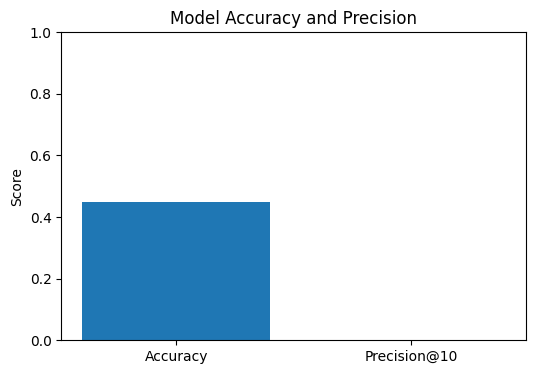

In [19]:
plt.figure(figsize=(6,4))
plt.bar(["Accuracy", "Precision@10"], [np.mean(accuracies), np.mean(precisions)])
plt.title("Model Accuracy and Precision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()